# Proyecto NLP – Análisis de Sentimiento en Tweets  
## Entrenamiento binario (0/4) + Neutral por descarte (3 clases)

**Idea central (tu enfoque):**  
Entrenamos modelos **binarios** en el dataset grande (solo 0/4).  
Luego, al predecir en el dataset chico (0/2/4), asignamos:

- **Negativo (0)** si el modelo está muy seguro de negativo  
- **Positivo (4)** si está muy seguro de positivo  
- **Neutral (2)** si está en zona de incertidumbre (**“por descarte”**)  

Esto se implementa con umbrales de probabilidad.

**Requisitos de consigna cubiertos:**
- 2 modelos supervisados (algoritmos de clase).
- Evaluación interna (train/valid) para cada modelo.
- Evaluación externa en dataset 0/2/4 con 3 polaridades derivadas.
- Comparación con modelo pre-entrenado (TextBlob).
- Métrica extra: similitud coseno con TF‑IDF.

> En esta notebook cada modelo está en una sección separada, con métricas independientes.


In [1]:
# ===== 0. Imports y configuración =====
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import matplotlib.pyplot as plt

# TextBlob baseline (opcional)
try:
    from textblob import TextBlob
    TEXTBLOB_AVAILABLE = True
except ImportError:
    TEXTBLOB_AVAILABLE = False
    print("TextBlob no está instalado. Si querés usarlo: pip install textblob")


## 0.1 Instalación de spaCy (una sola vez)

Corré esta celda solo si no tenés spaCy y el modelo en tu entorno.


In [2]:
# ===== 0.1 Instalar spaCy y modelo de inglés =====
!pip -q install spacy==3.7.2
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.2 MB/s eta 0:00:00 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 1. Carga de datos

Archivos esperados en la carpeta:
- `training.1600000.processed.noemoticon.csv`  (grande, 0/4)
- `testdata.manual.2009.06.14.csv`             (chico, 0/2/4)

Columnas:
0 polarity, 1 id, 2 date, 3 query, 4 user, 5 text


In [3]:
# ===== 1. Carga de datos =====
train_path = "training.1600000.processed.noemoticon.csv"
test_path  = "testdata.manual.2009.06.14.csv"

cols = ["polarity","id","date","query","user","text"]

train_df = pd.read_csv(train_path, encoding="latin-1", header=None, names=cols)
test_df  = pd.read_csv(test_path,  encoding="latin-1", header=None, names=cols)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (1600000, 6)
Test shape: (498, 6)


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## 2. EDA corto (opcional)

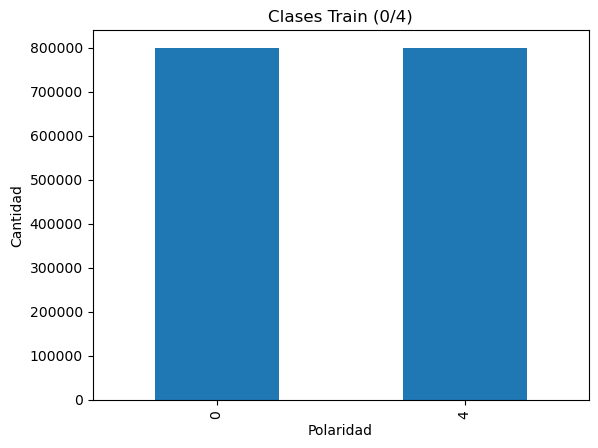

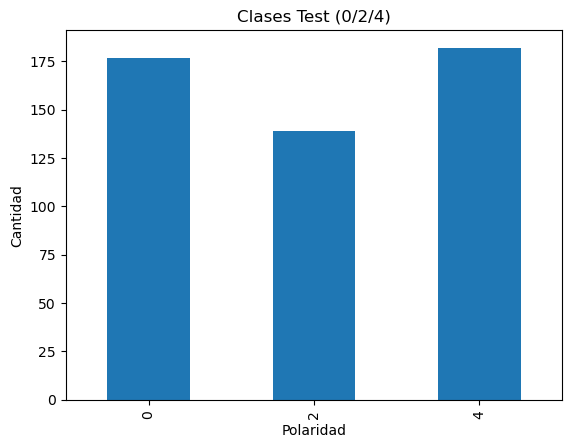

In [4]:
# ===== 2. EDA =====
def plot_class_distribution(df, title):
    counts = df["polarity"].value_counts().sort_index()
    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Polaridad")
    plt.ylabel("Cantidad")
    plt.show()

plot_class_distribution(train_df, "Clases Train (0/4)")
plot_class_distribution(test_df, "Clases Test (0/2/4)")


## 3. Preprocesamiento + Lematización

1) Limpieza básica  
2) Lematización con spaCy + stopwords  

> Para acelerar, usamos `nlp.pipe`.


In [5]:
# ===== 3. Limpieza básica =====
url_re = re.compile(r"https?://\S+|www\.\S+")
mention_re = re.compile(r"@\w+")
hashtag_re = re.compile(r"#(\w+)")

def clean_tweet(text: str) -> str:
    text = str(text).lower()
    text = url_re.sub(" ", text)
    text = mention_re.sub(" ", text)
    text = hashtag_re.sub(r"\1", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_clean"] = train_df["text"].apply(clean_tweet)
test_df["text_clean"]  = test_df["text"].apply(clean_tweet)

train_df[["text","text_clean"]].head()


,text,text_clean
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that's a bummer you shoulda got david car...
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it's not behaving at all i'm mad why am i h...


In [6]:
# ===== 3.1 Lematización =====
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.max_length = 2_000_000

def lemmatize_texts(texts, batch_size=2000, n_process=2):
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
        toks = [
            t.lemma_.lower()
            for t in doc
            if t.is_alpha and t.lemma_ != "-PRON-" and t.text.lower() not in STOP_WORDS
        ]
        out.append(" ".join(toks))
    return out

train_df["text_lemma"] = lemmatize_texts(train_df["text_clean"].tolist(), n_process=2)
test_df["text_lemma"]  = lemmatize_texts(test_df["text_clean"].tolist(),  n_process=2)

train_df[["text_clean","text_lemma"]].head()


,text_clean,text_lemma
0,awww that's a bummer you shoulda got david car...,awww bummer shoulda get david carr day d
1,is upset that he can't update his facebook by ...,upset update facebook texte cry result school ...
2,i dived many times for the ball managed to sav...,dive time ball manage save rest bound
3,my whole body feels itchy and like its on fire,body feel itchy like fire
4,no it's not behaving at all i'm mad why am i h...,behave mad


## 4. Split interno para entrenamiento binario

In [7]:
# ===== 4. Split =====
X = train_df["text_lemma"]
y = train_df["polarity"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train interno:", X_train.shape, "Valid interno:", X_valid.shape)


Train interno: (1280000,) Valid interno: (320000,)


# Modelo 1 – Logistic Regression + TF‑IDF

In [8]:
# ===== Modelo 1: Logistic Regression =====
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
    ("clf", LogisticRegression(max_iter=300, n_jobs=-1))
])

lr_pipe.fit(X_train, y_train)

# Evaluación interna
lr_pred_valid = lr_pipe.predict(X_valid)
lr_acc_valid = accuracy_score(y_valid, lr_pred_valid)
lr_f1_valid  = f1_score(y_valid, lr_pred_valid, average="weighted")

print("LR valid acc:", round(lr_acc_valid,4), "f1w:", round(lr_f1_valid,4))
print(classification_report(y_valid, lr_pred_valid))
print("Confusion matrix:\n", confusion_matrix(y_valid, lr_pred_valid))


LR valid acc: 0.7794 f1w: 0.7793
              precision    recall  f1-score   support

           0       0.79      0.76      0.77    160000
           4       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000

Confusion matrix:
 [[121094  38906]
 [ 31694 128306]]


## Modelo 1 en test externo (3 clases por descarte)

In [9]:
# ===== LR en test externo =====
X_test_all = test_df["text_lemma"]
y_test_all = test_df["polarity"]

lr_proba_pos = lr_pipe.predict_proba(X_test_all)[:,1]

low_thr, high_thr = 0.4, 0.6
lr_pred_3 = np.where(lr_proba_pos > high_thr, 4,
             np.where(lr_proba_pos < low_thr, 0, 2))

print("LR test 3‑clases:")
print(classification_report(y_test_all, lr_pred_3))
print("Confusion matrix:\n", confusion_matrix(y_test_all, lr_pred_3))

# Referencia binaria real (filtrando neutrales)
mask_bin = y_test_all.isin([0,4])
print("LR test binario (0/4) referencia:")
print(classification_report(y_test_all[mask_bin], lr_pipe.predict(X_test_all[mask_bin])))


LR test 3‑clases:
              precision    recall  f1-score   support

           0       0.77      0.65      0.70       177
           2       0.44      0.32      0.37       139
           4       0.57      0.76      0.65       182

    accuracy                           0.60       498
   macro avg       0.59      0.58      0.58       498
weighted avg       0.60      0.60      0.59       498

Confusion matrix:
 [[115  35  27]
 [ 15  45  79]
 [ 20  23 139]]
LR test binario (0/4) referencia:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       177
           4       0.79      0.83      0.81       182

    accuracy                           0.81       359
   macro avg       0.81      0.80      0.80       359
weighted avg       0.81      0.81      0.80       359



# Modelo 2 – Multinomial Naive Bayes + TF‑IDF

In [10]:
# ===== Modelo 2: Multinomial Naive Bayes =====
nb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
    ("clf", MultinomialNB())
])

nb_pipe.fit(X_train, y_train)

# Evaluación interna
nb_pred_valid = nb_pipe.predict(X_valid)
nb_acc_valid = accuracy_score(y_valid, nb_pred_valid)
nb_f1_valid  = f1_score(y_valid, nb_pred_valid, average="weighted")

print("NB valid acc:", round(nb_acc_valid,4), "f1w:", round(nb_f1_valid,4))
print(classification_report(y_valid, nb_pred_valid))
print("Confusion matrix:\n", confusion_matrix(y_valid, nb_pred_valid))


NB valid acc: 0.764 f1w: 0.764
              precision    recall  f1-score   support

           0       0.77      0.76      0.76    160000
           4       0.76      0.77      0.76    160000

    accuracy                           0.76    320000
   macro avg       0.76      0.76      0.76    320000
weighted avg       0.76      0.76      0.76    320000

Confusion matrix:
 [[121889  38111]
 [ 37406 122594]]


## Modelo 2 en test externo (3 clases por descarte)

In [11]:
# ===== NB en test externo =====
nb_proba_pos = nb_pipe.predict_proba(X_test_all)[:,1]

nb_pred_3 = np.where(nb_proba_pos > high_thr, 4,
             np.where(nb_proba_pos < low_thr, 0, 2))

print("NB test 3‑clases:")
print(classification_report(y_test_all, nb_pred_3))
print("Confusion matrix:\n", confusion_matrix(y_test_all, nb_pred_3))

print("NB test binario (0/4) referencia:")
print(classification_report(y_test_all[mask_bin], nb_pipe.predict(X_test_all[mask_bin])))


NB test 3‑clases:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70       177
           2       0.46      0.41      0.44       139
           4       0.58      0.68      0.63       182

    accuracy                           0.60       498
   macro avg       0.59      0.59      0.59       498
weighted avg       0.60      0.60      0.60       498

Confusion matrix:
 [[120  30  27]
 [ 21  57  61]
 [ 23  36 123]]
NB test binario (0/4) referencia:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       177
           4       0.79      0.81      0.80       182

    accuracy                           0.79       359
   macro avg       0.79      0.79      0.79       359
weighted avg       0.79      0.79      0.79       359



## 5. Comparación rápida de ambos modelos (resumen)

In [12]:
# ===== 5. Resumen comparativo =====
summary = pd.DataFrame({
    "modelo": ["Logistic Regression", "Naive Bayes"],
    "acc_valid": [lr_acc_valid, nb_acc_valid],
    "f1w_valid": [lr_f1_valid,  nb_f1_valid],
})
summary


,modelo,acc_valid,f1w_valid
0,Logistic Regression,0.779375,0.779263
1,Naive Bayes,0.764009,0.764008


## 6. Baseline pre‑entrenado: TextBlob (3 clases)

In [13]:
# ===== 6. TextBlob baseline =====
def textblob_predict_3(text):
    pol = TextBlob(text).sentiment.polarity
    if pol > 0.1:
        return 4
    elif pol < -0.1:
        return 0
    else:
        return 2

if TEXTBLOB_AVAILABLE:
    tb_pred_3 = test_df["text_clean"].apply(textblob_predict_3).values
    print("TextBlob test 3‑clases:")
    print(classification_report(y_test_all, tb_pred_3))
    print("Confusion matrix:\n", confusion_matrix(y_test_all, tb_pred_3))
else:
    print("TextBlob no disponible.")


TextBlob test 3‑clases:
              precision    recall  f1-score   support

           0       0.82      0.40      0.53       177
           2       0.50      0.73      0.60       139
           4       0.62      0.72      0.67       182

    accuracy                           0.61       498
   macro avg       0.65      0.62      0.60       498
weighted avg       0.66      0.61      0.60       498

Confusion matrix:
 [[ 70  58  49]
 [  6 102  31]
 [  9  42 131]]


## 7. Métrica extra: Similitud coseno entre clases

In [ ]:
# ===== 7. Similitud coseno =====
vectorizer = lr_pipe.named_steps["tfidf"]
X_vec = vectorizer.transform(X_test_all)

idx_pos = np.where(y_test_all.values == 4)[0]
idx_neg = np.where(y_test_all.values == 0)[0]
idx_neu = np.where(y_test_all.values == 2)[0]

def mean_cosine(idxs_a, idxs_b, n_sample=200):
    rng = np.random.default_rng(0)
    a = rng.choice(idxs_a, size=min(n_sample, len(idxs_a)), replace=False)
    b = rng.choice(idxs_b, size=min(n_sample, len(idxs_b)), replace=False)
    sim = cosine_similarity(X_vec[a], X_vec[b])
    return sim.mean()

print("Cos(pos,pos):", round(mean_cosine(idx_pos, idx_pos),4))
print("Cos(neg,neg):", round(mean_cosine(idx_neg, idx_neg),4))
print("Cos(pos,neg):", round(mean_cosine(idx_pos, idx_neg),4))
print("Cos(neu,pos):", round(mean_cosine(idx_neu, idx_pos),4))
print("Cos(neu,neg):", round(mean_cosine(idx_neu, idx_neg),4))


## 8. Conclusiones (completar)